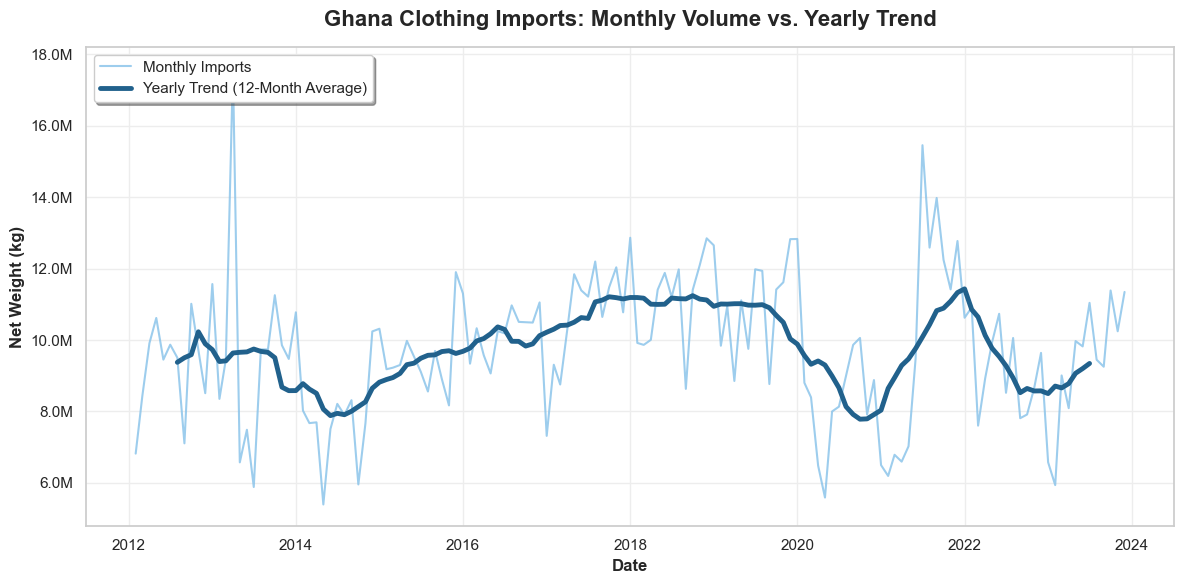

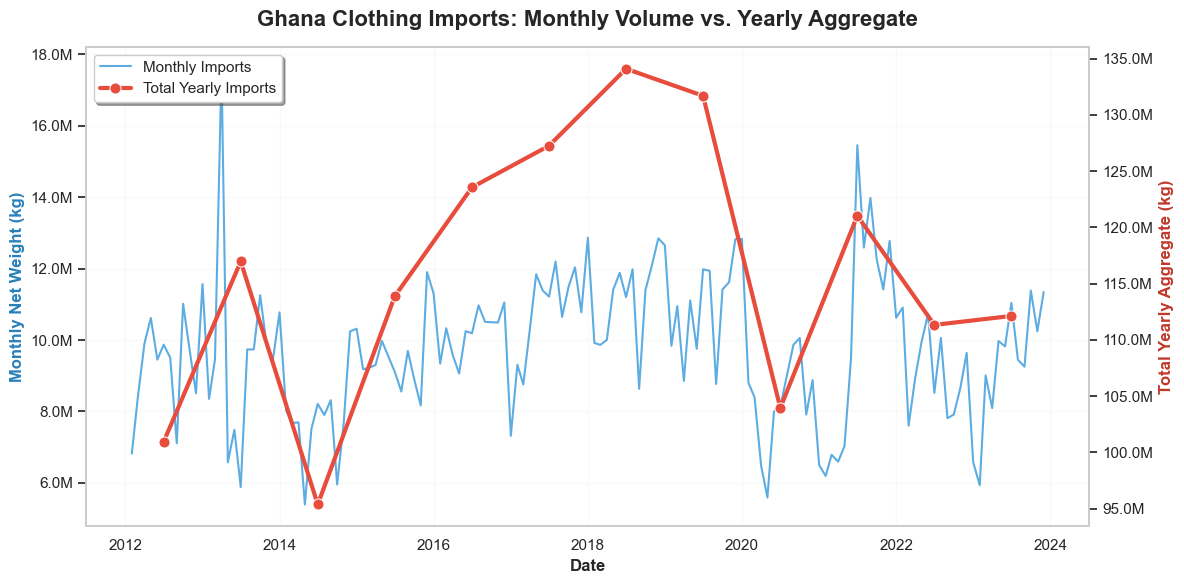

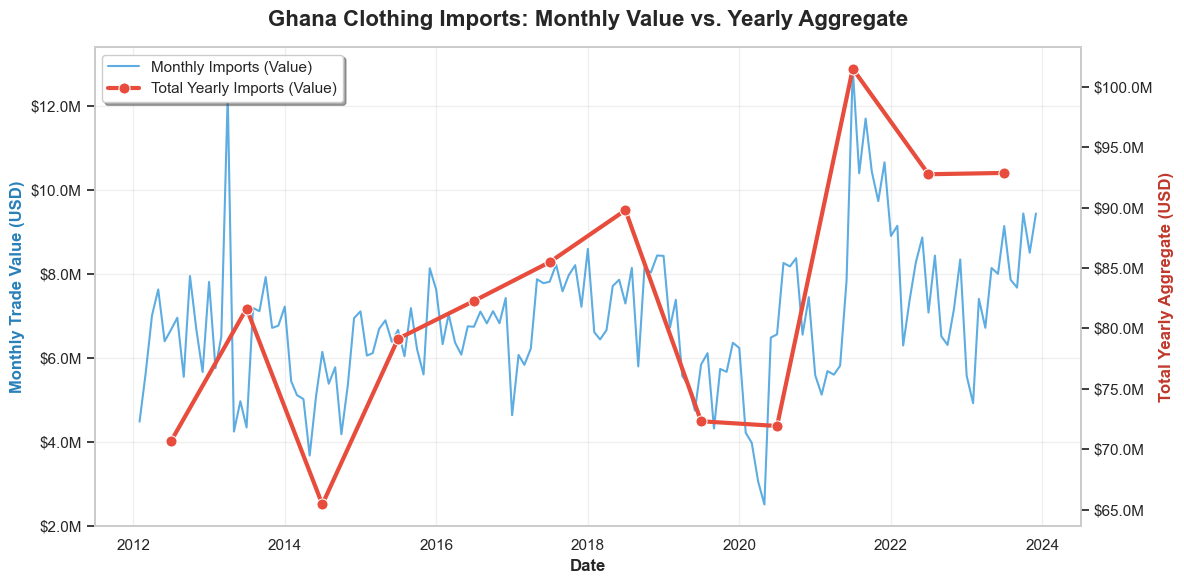

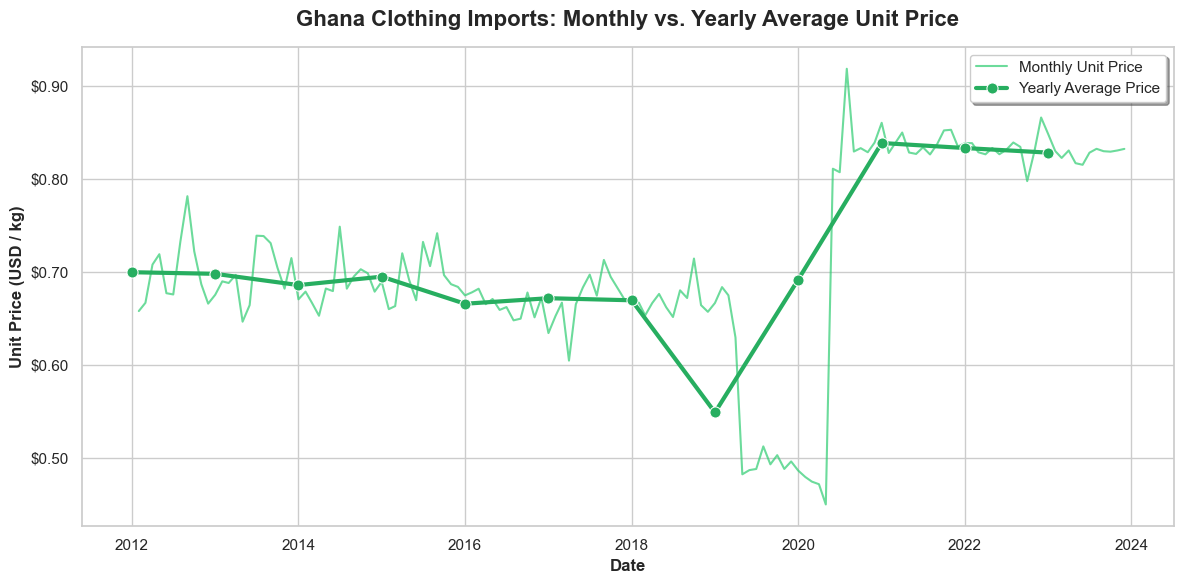

In [3]:
# ==========================================
# VISUALIZATIONS CODE
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
%matplotlib inline 

# Loading data (absolute path)
file_path = "/Users/talia/Desktop/Master_Merged_Analysis_Data 20260909.xlsx" 
#load data (relative path after downloading directly from github)
#file_path = "/Second-Hand-Clothing-and-Textile-Waste-in-Accra/data/merged/Master_Merged_Analysis_Data 20260909.xlsx"
#the excel sheet name that contains all required data for further analysis
sheet = "All land fills night"
df_cleaned = pd.read_excel(file_path, sheet_name=sheet, header=1)

# Fix Variable Names & Dates
COL_WEIGHT = "net_weight_kg"
COL_VALUE = "trade_value_usd"
COL_PRICE = "Price_Per_Kg"
COL_FIRES = "Landfill_Fires"

# Convert 'Month_Key' (e.g., '2012-02') to standard datetime for smooth plotting
df_cleaned['date'] = pd.to_datetime(df_cleaned['Month_Key'])

# Data Prep for Graphs
# Drop blank rows
df_cleaned.dropna(subset=['date'], inplace=True)

# convert year to a strict integer (remove the .0)
df_cleaned['year'] = df_cleaned['date'].dt.year.astype(int)

# chronological ordering
df_cleaned = df_cleaned.sort_values(by='date').reset_index(drop=True)

# fill blank fires with 0
df_cleaned['Landfill_Fires'] = df_cleaned['Landfill_Fires'].fillna(0)

# 12-Month Rolling Trend (Weight)
df_cleaned['yearly_trend'] = df_cleaned[COL_WEIGHT].rolling(window=12, center=True).mean()

# Yearly Aggregate Sum (Anchored to July 1 for visual centering)
df_yearly_agg = df_cleaned.groupby('year')[COL_WEIGHT].sum().reset_index()
df_yearly_agg['midpoint_date'] = pd.to_datetime(df_yearly_agg['year'].astype(str) + '-07-01')

# Yearly Average Price (Anchored to Jan 1)
df_yearly_price = df_cleaned.groupby('year').apply(
    lambda x: x[COL_VALUE].sum() / x[COL_WEIGHT].sum()
).reset_index(name='yearly_price')
df_yearly_price['start_date'] = pd.to_datetime(df_yearly_price['year'].astype(str) + '-01-01')

# Yearly Aggregate for value
df_yearly_agg_value = df_cleaned.groupby('year')[COL_VALUE].sum().reset_index()
df_yearly_agg_value['midpoint_date'] = pd.to_datetime(df_yearly_agg_value['year'].astype(str) + '-07-01')

# =========================================================
# GRAPH 1: Monthly vs Yearly Trend
# =========================================================
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "white", "grid.color": "#ededed"})
sns.lineplot(data=df_cleaned, x='date', y=COL_WEIGHT, color="#85c1e9", linewidth=1.5, alpha=0.8, label="Monthly Imports")
sns.lineplot(data=df_cleaned, x='date', y='yearly_trend', color="#21618c", linewidth=3.5, label="Yearly Trend (12-Month Average)")

plt.title("Ghana Clothing Imports: Monthly Volume vs. Yearly Trend", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12, fontweight='bold')
plt.ylabel("Net Weight (kg)", fontsize=12, fontweight='bold')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x * 1e-6:.1f}M'))
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()


# =========================================================
# GRAPH 2: Dual-Axis Monthly vs Yearly Aggregate (Weight)
# =========================================================
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "white"})

sns.lineplot(data=df_cleaned, x='date', y=COL_WEIGHT, ax=ax1, color="#3498db", linewidth=1.5, alpha=0.8, label="Monthly Imports")
ax2 = ax1.twinx()
sns.lineplot(data=df_yearly_agg, x='midpoint_date', y=COL_WEIGHT, ax=ax2, color="#e74c3c", linewidth=3, marker="o", markersize=8, label="Total Yearly Imports")

plt.title("Ghana Clothing Imports: Monthly Volume vs. Yearly Aggregate", fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel("Date", fontsize=12, fontweight='bold')
ax1.set_ylabel("Monthly Net Weight (kg)", fontsize=12, fontweight='bold', color="#2980b9")
ax2.set_ylabel("Total Yearly Aggregate (kg)", fontsize=12, fontweight='bold', color="#c0392b")

ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x * 1e-6:.1f}M'))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x * 1e-6:.1f}M'))

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, shadow=True)
ax2.get_legend().remove()
ax1.grid(True, alpha=0.3)
ax2.grid(False)
plt.tight_layout()
plt.show()


# =========================================================
# GRAPH 3: Dual-Axis Monthly VALUE vs Yearly Aggregate
# =========================================================
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "white"})

sns.lineplot(data=df_cleaned, x='date', y=COL_VALUE, ax=ax1, color="#3498db", linewidth=1.5, alpha=0.8, label="Monthly Imports (Value)")
ax2 = ax1.twinx()
sns.lineplot(data=df_yearly_agg_value, x='midpoint_date', y=COL_VALUE, ax=ax2, color="#e74c3c", linewidth=3, marker="o", markersize=8, label="Total Yearly Imports (Value)")

plt.title("Ghana Clothing Imports: Monthly Value vs. Yearly Aggregate", fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel("Date", fontsize=12, fontweight='bold')
ax1.set_ylabel("Monthly Trade Value (USD)", fontsize=12, fontweight='bold', color="#2980b9")
ax2.set_ylabel("Total Yearly Aggregate (USD)", fontsize=12, fontweight='bold', color="#c0392b")

ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x * 1e-6:.1f}M'))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x * 1e-6:.1f}M'))

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, shadow=True)
ax2.get_legend().remove()
ax1.grid(True, alpha=0.3)
ax2.grid(False)
plt.tight_layout()
plt.show()


# =========================================================
# GRAPH 4: Unit Price (Monthly vs Yearly Average)
# =========================================================
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "white"})

sns.lineplot(data=df_cleaned, x='date', y=COL_PRICE, color="#2ecc71", linewidth=1.5, alpha=0.7, label="Monthly Unit Price")
sns.lineplot(data=df_yearly_price, x='start_date', y='yearly_price', color="#27ae60", linewidth=3, marker="o", markersize=8, label="Yearly Average Price")

plt.title("Ghana Clothing Imports: Monthly vs. Yearly Average Unit Price", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12, fontweight='bold')
plt.ylabel("Unit Price (USD / kg)", fontsize=12, fontweight='bold')
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('$%1.2f'))
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()


  OLS MODEL 1: IMPORT WEIGHT (LOG) VS FIRE AVG  

Window   N  Zero Count    Coef  Std P-Val Std Sig  HAC P-Val HAC Sig     R2
  1-Mo 143          47  3.2265     0.0093      **     0.0572      No 0.0471
  2-Mo 142          26  2.4024     0.0394       *     0.1315      No 0.0300
  3-Mo 141          14  1.5893     0.1491      No     0.2429      No 0.0149
  4-Mo 140           6  0.7929     0.4482      No     0.5528      No 0.0042
  5-Mo 139           2  0.2576     0.7968      No     0.8626      No 0.0005
  6-Mo 138           1  0.0117     0.9903      No     0.9942      No 0.0000
  7-Mo 137           0  0.0002     0.9999      No     0.9999      No 0.0000
  8-Mo 136           0  0.1020     0.9107      No     0.9464      No 0.0001
  9-Mo 135           0 -0.0033     0.9970      No     0.9982      No 0.0000
 10-Mo 134           0  0.0201     0.9817      No     0.9885      No 0.0000
 11-Mo 133           0 -0.0741     0.9311      No     0.9565      No 0.0001
 12-Mo 132           0 -0.2505     0.

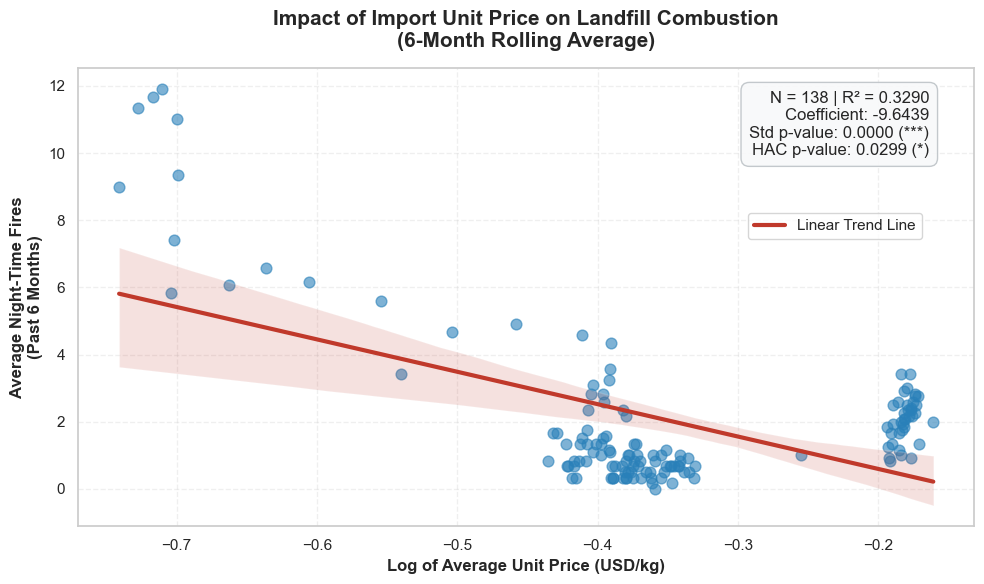

In [4]:
# ==========================================
# OLS REGRESSION ANALYSIS & SCATTERPLOT (STD + HAC)
# ==========================================
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# REGRESSION CONTROL PANEL
# ==========================================
USE_LOG_FIRE = False
USE_LOG_PRICE = True
# ==========================================

if 'Landfill_Fires' not in df_cleaned.columns:
    print("Warning: Fire column 'Landfill_Fires' not found. Cannot run regressions.")
else:
    results_weight = []
    results_price = []
    windows = range(1, 13)

    for w in windows:
        df_temp = df_cleaned.copy()

        # Calculate Rolling averages
        df_temp['Fire_Avg'] = df_temp['Landfill_Fires'].rolling(window=w).mean()
        df_temp['Price_Avg'] = df_temp['Price_Per_Kg'].rolling(window=w).mean()

        # --- Count the zeros for this window ---
        zero_fires = (df_temp['Fire_Avg'] == 0).sum()

        # Apply Transformations (Replacing 0 with 0.1 for the log)
        df_temp['log_weight'] = np.log(df_temp['net_weight_kg'].replace(0, 0.1))

        if USE_LOG_FIRE:
            df_temp['y_fire'] = np.log(df_temp['Fire_Avg'].replace(0, 0.1))
            fire_label = "Log(Fire Avg)"
        else:
            df_temp['y_fire'] = df_temp['Fire_Avg']
            fire_label = "Fire Avg"

        if USE_LOG_PRICE:
            df_temp['x_price'] = np.log(df_temp['Price_Avg'].replace(0, 0.1))
            price_label = "Log(Price Avg)"
        else:
            df_temp['x_price'] = df_temp['Price_Avg']
            price_label = "Price Avg"

        # Drop standard NAs (will no longer drop the 0s since they are now 0.1)
        df_temp.dropna(subset=['log_weight', 'x_price', 'y_fire'], inplace=True)
        
        if len(df_temp) > 20:
            try:
                def get_sig(p):
                    if p < 0.001: return "***"
                    elif p < 0.01: return "**"
                    elif p < 0.05: return "*"
                    else: return "No"

                # MODEL 1: Fires vs Log Weight
                mod_w_std = smf.ols('y_fire ~ log_weight', data=df_temp).fit()
                mod_w_hac = smf.ols('y_fire ~ log_weight', data=df_temp).fit(cov_type='HAC', cov_kwds={'maxlags': w})
                
                coef_w = mod_w_std.params.get('log_weight', np.nan)
                p_w_std = mod_w_std.pvalues.get('log_weight', np.nan)
                p_w_hac = mod_w_hac.pvalues.get('log_weight', np.nan)

                results_weight.append({
                    'Window': f"{w}-Mo",
                    'N': int(mod_w_std.nobs),
                    'Zero Count': int(zero_fires),
                    'Coef': round(coef_w, 4),
                    'Std P-Val': round(p_w_std, 4),
                    'Std Sig': get_sig(p_w_std),
                    'HAC P-Val': round(p_w_hac, 4),
                    'HAC Sig': get_sig(p_w_hac),
                    'R2': round(mod_w_std.rsquared, 4)
                })

                # MODEL 2: Fires vs Price
                mod_p_std = smf.ols('y_fire ~ x_price', data=df_temp).fit()
                mod_p_hac = smf.ols('y_fire ~ x_price', data=df_temp).fit(cov_type='HAC', cov_kwds={'maxlags': w})
                
                coef_p = mod_p_std.params.get('x_price', np.nan)
                p_p_std = mod_p_std.pvalues.get('x_price', np.nan)
                p_p_hac = mod_p_hac.pvalues.get('x_price', np.nan)

                results_price.append({
                    'Window': f"{w}-Mo",
                    'N': int(mod_p_std.nobs),
                    'Zero Count': int(zero_fires),
                    'Coef': round(coef_p, 4),
                    'Std P-Val': round(p_p_std, 4),
                    'Std Sig': get_sig(p_p_std),
                    'HAC P-Val': round(p_p_hac, 4),
                    'HAC Sig': get_sig(p_p_hac),
                    'R2': round(mod_p_std.rsquared, 4)
                })
            except Exception as e:
                pass

    # --- PRINT OLS RESULT TABLES ---
    print("\n=========================================================================")
    print(f"  OLS MODEL 1: IMPORT WEIGHT (LOG) VS {fire_label.upper()}  ")
    print("=========================================================================\n")
    print(pd.DataFrame(results_weight).to_string(index=False))
    print("\n")

    print("=========================================================================")
    print(f"  OLS MODEL 2: {price_label.upper()} VS {fire_label.upper()} ")
    print("=========================================================================\n")
    print(pd.DataFrame(results_price).to_string(index=False))
    print("\n")


# ==========================================
# DYNAMIC SCATTERPLOT (6-MONTH)
# ==========================================
w = 6
df_final = df_cleaned.copy()

df_final['Fire_Avg'] = df_final['Landfill_Fires'].rolling(window=w).mean()
df_final['Price_Avg'] = df_final['Price_Per_Kg'].rolling(window=w).mean()

# Diagnostic print for the scatterplot
zero_fires_6m = (df_final['Fire_Avg'] == 0).sum()
print(f"--- Generating Scatterplot (6-Month {fire_label} vs. {price_label}) ---")
print(f"--- Found {zero_fires_6m} instances of true 0s in the 6-month fire average ---")

DRAW_LOG_TRENDLINE = True

if USE_LOG_FIRE:
    df_final['y_fire'] = np.log(df_final['Fire_Avg'].replace(0, 0.1))
    y_axis_label = f'Log of Average Night-Time Fires\n(Past {w} Months)'
else:
    df_final['y_fire'] = df_final['Fire_Avg']
    y_axis_label = f'Average Night-Time Fires\n(Past {w} Months)'

if USE_LOG_PRICE:
    df_final['x_price'] = np.log(df_final['Price_Avg'].replace(0, 0.1))
    x_axis_label = 'Log of Average Unit Price (USD/kg)'
else:
    df_final['x_price'] = df_final['Price_Avg']
    x_axis_label = 'Average Unit Price (USD/kg)'

df_final.dropna(subset=['x_price', 'y_fire'], inplace=True)

if DRAW_LOG_TRENDLINE and not USE_LOG_PRICE:
    formula = 'y_fire ~ np.log(x_price)'
    model_std = smf.ols(formula, data=df_final).fit()
    model_hac = smf.ols(formula, data=df_final).fit(cov_type='HAC', cov_kwds={'maxlags': w})
    p_std = model_std.pvalues['np.log(x_price)']
    p_hac = model_hac.pvalues['np.log(x_price)']
    coef = model_std.params['np.log(x_price)']
    line_label = 'Logarithmic Trend Line'
    r2_label = 'Log Curve R²'
else:
    formula = 'y_fire ~ x_price'
    model_std = smf.ols(formula, data=df_final).fit()
    model_hac = smf.ols(formula, data=df_final).fit(cov_type='HAC', cov_kwds={'maxlags': w})
    p_std = model_std.pvalues['x_price']
    p_hac = model_hac.pvalues['x_price']
    coef = model_std.params['x_price']
    line_label = 'Linear Trend Line'
    r2_label = 'Standard R²'

r_squared = model_std.rsquared
r_val = np.sign(coef) * np.sqrt(r_squared)
n_obs = int(model_std.nobs)

plt.figure(figsize=(10, 6))
sns.regplot(
    x='x_price',
    y='y_fire',
    data=df_final,
    logx=DRAW_LOG_TRENDLINE if not USE_LOG_PRICE else False,
    scatter_kws={'color': '#2980b9', 's': 60, 'alpha': 0.6, 'label': 'Monthly Observations'},
    line_kws={'color': '#c0392b', 'linewidth': 3, 'label': line_label},
    ci=95
)

plt.title(f'Impact of Import Unit Price on Landfill Combustion\n({w}-Month Rolling Average)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel(x_axis_label, fontsize=12, fontweight='bold')
plt.ylabel(y_axis_label, fontsize=12, fontweight='bold')

sig_label_std = "***" if p_std < 0.001 else "**" if p_std < 0.01 else "*" if p_std < 0.05 else "No"
sig_label_hac = "***" if p_hac < 0.001 else "**" if p_hac < 0.01 else "*" if p_hac < 0.05 else "No"

text_str = (f"N = {n_obs} | R² = {r_squared:.4f}\n"
            f"Coefficient: {coef:.4f}\n"
            f"Std p-value: {p_std:.4f} ({sig_label_std})\n"
            f"HAC p-value: {p_hac:.4f} ({sig_label_hac})")

plt.gca().text(0.95, 0.95, text_str, transform=plt.gca().transAxes, fontsize=12,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', alpha=0.9, edgecolor='#bdc3c7'))

plt.legend(loc='upper right', bbox_to_anchor=(0.95, 0.70))
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# APPENDIX - PRICE ELASTICITY
# ==========================================
#make columns numeric 
df_appendix = df_cleaned.copy()
df_appendix[COL_WEIGHT] = pd.to_numeric(df_appendix[COL_WEIGHT], errors='coerce')
df_appendix[COL_PRICE] = pd.to_numeric(df_appendix[COL_PRICE], errors='coerce')

#Drop missing values just in case
df_appendix.dropna(subset=[COL_WEIGHT, COL_PRICE], inplace=True)


# Calculate Correlation and Fit Model for Stats Box
formula_elasticity = f"{COL_PRICE} ~ {COL_WEIGHT}"
model_elasticity = smf.ols(formula_elasticity, data=df_appendix).fit()

p_val_elast = model_elasticity.pvalues[COL_WEIGHT]
coef_elast = model_elasticity.params[COL_WEIGHT]
r_squared_elast = model_elasticity.rsquared
correlation = np.sign(coef_elast) * np.sqrt(r_squared_elast)

# Build Plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "white", "grid.color": "#ededed"})

sns.regplot(
    x=COL_WEIGHT,
    y=COL_PRICE,
    data=df_appendix,
    scatter_kws={'color': '#2980b9', 's': 70, 'alpha': 0.6, 'label': 'Monthly Observations'},
    line_kws={'color': '#c0392b', 'linewidth': 3, 'label': 'Linear Trend Line'},
    ci=95
)

# Dynamic Formatting
plt.title("Price Elasticity: Quantity vs. Unit Price", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Total Quantity Imported (kg)", fontsize=12, fontweight='bold')
plt.ylabel("Price per KG (USD)", fontsize=12, fontweight='bold')

# Format X-axis to Millions (M) and Y-axis to Currency
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x*1e-6:.1f}M'))
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('$%1.2f'))

# Statistical Box 
sig_label_elast = "Significant (***)" if p_val_elast < 0.001 else "Significant (**)" if p_val_elast < 0.01 else "Significant (*)" if p_val_elast < 0.05 else "Not Significant"
text_str_elast = f"Correlation (r): {correlation:.4f}\nStandard R²: {r_squared_elast:.4f}\n{sig_label_elast}"

plt.gca().text(0.95, 0.95, text_str_elast, transform=plt.gca().transAxes, fontsize=12,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', alpha=0.9, edgecolor='#bdc3c7'))

# Adjust legend location
plt.legend(loc='upper right', bbox_to_anchor=(0.95, 0.75))
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# REVIEWER ROBUSTNESS CHECKS
# ==========================================
print("--- Running Reviewer Robustness Checks (6-Month Window) ---")

w = 6
df_robust = df_cleaned.copy()
df_robust['Fire_Avg'] = df_robust[COL_FIRES].rolling(window=w).mean()
df_robust['Price_Avg'] = df_robust[COL_PRICE].rolling(window=w).mean()

# Drop NaNs generated by rolling average
df_robust.dropna(subset=['Price_Avg', 'Fire_Avg'], inplace=True)

# ---------------------------------------------------------
# TEST 1: "Without 2019-2020" Model
# ---------------------------------------------------------
# Filter out the years 2019 and 2020
df_no_covid = df_robust[~df_robust['year'].isin([2019, 2020])]

mod_no_covid = smf.ols('Fire_Avg ~ Price_Avg', data=df_no_covid).fit()
p_val_1 = mod_no_covid.pvalues['Price_Avg']

print("\n[TEST 1: Excluding 2019 & 2020]")
print(f"Price Coefficient: {mod_no_covid.params['Price_Avg']:.4f}")
print(f"P-Value: {p_val_1:.4f} " + ("(Significant)" if p_val_1 < 0.05 else "(Not Significant)"))

#graphs for test 1
#graph style
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "white", "grid.color": "#ededed"})

#graph for test 1 - without 2019-2020
sns.regplot(
    x='Price_Avg', 
    y='Fire_Avg', 
    data=df_no_covid, 
    ax=axes[0],
    scatter_kws={'color': '#95a5a6', 'alpha': 0.6, 's': 60},
    line_kws={'color': '#e74c3c', 'linewidth': 3}
)

axes[0].set_title("Test 1: Excluding 2019 & 2020", fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel("Average Unit Price (USD/kg)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Average Night-Time Fires", fontsize=12, fontweight='bold')

# Stats box for Graph 1
text_1 = f"Coefficient: {mod_no_covid.params['Price_Avg']:.4f}\nP-Value: {mod_no_covid.pvalues['Price_Avg']:.4f} (Sig)"
axes[0].text(0.05, 0.95, text_1, transform=axes[0].transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', alpha=0.9))

# ---------------------------------------------------------
# TEST 2: Calendar-Year Fixed Effects
# ---------------------------------------------------------
# C(year): treat the 'year' column as a categorical control
mod_fe = smf.ols('Fire_Avg ~ Price_Avg + C(year)', data=df_robust).fit()
p_val_2 = mod_fe.pvalues['Price_Avg']

print("\n[TEST 2: With Year Fixed Effects (C(year))]")
print(f"Price Coefficient: {mod_fe.params['Price_Avg']:.4f}")
print(f"P-Value: {p_val_2:.4f} " + ("(Significant)" if p_val_2 < 0.05 else "(Not Significant)"))


# ---------------------------------------------------------
# GRAPH 2: Year Fixed Effects (Simpson's Paradox Visualization)
# ---------------------------------------------------------
# 1. Calculate the predicted values from the Fixed Effects model
df_robust['FE_Predict'] = mod_fe.predict()

# 2. Plot the scatter points colored by year
sns.scatterplot(
    x='Price_Avg', 
    y='Fire_Avg', 
    hue='year', 
    palette='tab10', 
    data=df_robust, 
    ax=axes[1], 
    alpha=0.6, 
    s=60
)

# 3. Draw the parallel fixed-effects regression lines for each year
df_robust_sorted = df_robust.sort_values(['year', 'Price_Avg'])
for year in df_robust_sorted['year'].unique():
    subset = df_robust_sorted[df_robust_sorted['year'] == year]
    axes[1].plot(subset['Price_Avg'], subset['FE_Predict'], linewidth=2.5)

axes[1].set_title("Test 2: With Year Fixed Effects", fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel("Average Unit Price (USD/kg)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Average Night-Time Fires", fontsize=12, fontweight='bold')

# Stats box for Graph 2
text_2 = f"True FE Coefficient: {mod_fe.params['Price_Avg']:.4f}\nP-Value: {mod_fe.pvalues['Price_Avg']:.4f} (Sig)"
axes[1].text(0.05, 0.95, text_2, transform=axes[1].transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', alpha=0.9))

# Move the legend outside the plot
axes[1].legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# Further test: Fixed Effects WITHOUT 2019-2020
# ---------------------------------------------------------
mod_ultimate = smf.ols('Fire_Avg ~ Price_Avg + C(year)', data=df_no_covid).fit()
pval_ult = mod_ultimate.pvalues['Price_Avg']

print("\n[Year Fixed Effects WITHOUT 2019/2020]")
print(f"Coefficient: {mod_ultimate.params['Price_Avg']:.4f}")
print(f"P-Value: {pval_ult:.4f} " + ("(Significant)" if pval_ult < 0.05 else "(Not Significant)"))

# ==========================================
# VISUALIZING: Fixed Effects WITHOUT 2019-2020
# ==========================================

df_plot = df_no_covid.copy()
df_plot['FE_Predict_Ult'] = mod_ultimate.predict()

# plot style setup
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "white", "grid.color": "#ededed"})

sns.scatterplot(
    x='Price_Avg', 
    y='Fire_Avg', 
    hue='year', 
    palette='tab10', 
    data=df_plot, 
    alpha=0.6, 
    s=60
)

# regression lines for each year
df_plot_sorted = df_plot.sort_values(['year', 'Price_Avg'])
for year in df_plot_sorted['year'].unique():
    subset = df_plot_sorted[df_plot_sorted['year'] == year]
    plt.plot(subset['Price_Avg'], subset['FE_Predict_Ult'], linewidth=2.5)

# formatting
plt.title("Year Fixed Effects (Excluding 2019 & 2020)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Average Unit Price (USD/kg)", fontsize=12, fontweight='bold')
plt.ylabel("Average Night-Time Fires", fontsize=12, fontweight='bold')

# statistical Box
sig_label_ult = "Significant (***)" if pval_ult < 0.001 else "Significant (**)" if pval_ult < 0.01 else "Significant (*)" if pval_ult < 0.05 else "Not Significant"
text_str = (f"FE Coefficient: {mod_ultimate.params['Price_Avg']:.4f}\n"
            f"P-Value: {pval_ult:.4f} ({sig_label_ult})")

plt.gca().text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=12,
               verticalalignment='top', horizontalalignment='left',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', alpha=0.9, edgecolor='#bdc3c7'))

plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()